Starting Gradient Descent for n=100...


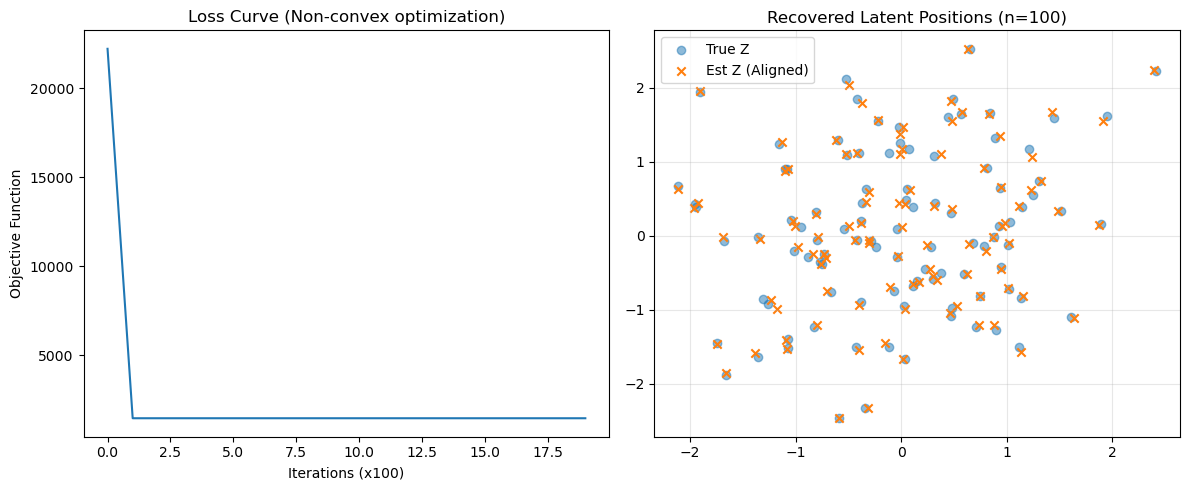

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# 1. GENERATE DATA (Same as before)
np.random.seed(4)
n = 100        # Much larger N possible now
d = 2 
sigma = 0.5

# Latent variables
mean = np.zeros(2 * d)
cov_block = np.block([[np.eye(d), sigma * np.eye(d)], [sigma * np.eye(d), np.eye(d)]])
ZX_samples = np.random.multivariate_normal(mean, cov_block, size=n)
Z_true, X_true = ZX_samples[:, :d], ZX_samples[:, d:]

# Adjacency matrices
A = Z_true @ Z_true.T + np.random.normal(0, 0.5, (n, n))
B = X_true @ X_true.T + np.random.normal(0, 0.5, (n, n))
A, B = (A + A.T)/2, (B + B.T)/2 # Symmetrize

# 2. FACTORIZED GRADIENT DESCENT (Burer-Monteiro)
# Initialize Z and X randomly
# NOTE: We use k=d here. If you suspect local minima, use k > d.
Z = np.random.randn(n, d) * 0.1
X = np.random.randn(n, d) * 0.1

lr = 0.001          # Learning rate
gamma = 1.0 / (2 * (1 - sigma**2))
iterations = 2000

losses = []

print(f"Starting Gradient Descent for n={n}...")

for i in range(iterations):
    # --- Compute Gradients ---
    # Gradient for Z
    # Derivation: d/dZ (1/2 ||A - ZZ^T||^2) = (ZZ^T - A)Z * 2 (approx factor depending on def)
    # We use the standard form: grad = (ZZ^T - A)Z
    grad_Z_data = (Z @ Z.T - A) @ Z
    grad_Z_reg  = gamma * (Z - sigma * X) # factor of 2 cancels with 1/2 in gamma term usually, keeping scaling simple
    
    # Gradient for X
    grad_X_data = (X @ X.T - B) @ X
    grad_X_reg  = gamma * (X - sigma * Z)
    
    # Total Gradients (Scaling factors 2 for the quadratic terms)
    # The exact gradient of 0.5*||A - ZZ.T||^2 is 2*(ZZ.T - A)Z if Z is not symmetric specific
    # Let's stick to standard implementation scale
    
    grad_Z = 2 * grad_Z_data + 2 * grad_Z_reg
    grad_X = 2 * grad_X_data + 2 * grad_X_reg
    
    # --- Update Steps ---
    Z = Z - lr * grad_Z
    X = X - lr * grad_X
    
    # --- Monitor Loss ---
    if i % 100 == 0:
        loss = 0.5*np.linalg.norm(A - Z@Z.T)**2 + \
               0.5*np.linalg.norm(B - X@X.T)**2 + \
               gamma * (np.linalg.norm(Z)**2 + np.linalg.norm(X)**2 - 2*sigma*np.trace(Z.T @ X))
        losses.append(loss)

# 3. VISUALIZATION
# Align Z_est to Z_true using Procrustes (since rotation is unidentifiable)
def align(source, target):
    u, _, vt = np.linalg.svd(target.T @ source)
    R = vt.T @ u.T
    return source @ R

Z_aligned = align(Z, Z_true)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(losses)
plt.title("Loss Curve (Non-convex optimization)")
plt.xlabel("Iterations (x100)")
plt.ylabel("Objective Function")

plt.subplot(1, 2, 2)
plt.scatter(Z_true[:, 0], Z_true[:, 1], alpha=0.5, label='True Z')
plt.scatter(Z_aligned[:, 0], Z_aligned[:, 1], marker='x', label='Est Z (Aligned)')
plt.legend()
plt.title(f"Recovered Latent Positions (n={n})")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()